<a href="https://colab.research.google.com/github/aabyyaann/scikit-learn-Cookbook/blob/main/Chapter2_Data_Wrangling_with_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2 - Data Wrangling with Pandas

Notebook ini merangkum Chapter 2 dari **scikit-learn Cookbook**.  
Fokus chapter ini adalah **data wrangling / manipulasi data menggunakan pandas** sebelum data dipakai untuk machine learning.

Pada chapter ini, kita akan mempelajari:
- cara membuat dan membaca DataFrame,
- memilih kolom dan baris,
- memfilter data,
- menangani missing values,
- menghapus duplikasi,
- mengubah tipe data,
- melakukan encoding sederhana,
- membuat fitur baru,
- agregasi dan grouping data,
- serta menyiapkan data agar lebih siap untuk proses machine learning berikutnya.

Karena chapter cookbook berisi banyak resep praktis, notebook ini dibuat dalam bentuk langkah-langkah kecil agar mudah dipahami dan mudah direproduksi di Google Colab maupun GitHub.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 20)

print("Library berhasil di-load.")

Library berhasil di-load.


## 1. Membuat Dataset Contoh

Agar seluruh resep pada chapter ini bisa dijalankan tanpa file eksternal, kita akan membuat dataset kecil buatan sendiri.  
Dataset ini mensimulasikan data pelanggan toko online dengan beberapa masalah umum pada data nyata, seperti:

- nilai yang hilang,
- data duplikat,
- format kategori yang tidak konsisten,
- kolom numerik yang perlu dibersihkan,
- dan kebutuhan membuat fitur baru.

In [2]:
data = {
    "customer_id": [1, 2, 3, 4, 5, 6, 6, 8, 9, 10],
    "name": ["Andi", "Budi", "Citra", "Dina", "Eka", "Fajar", "Fajar", "Gina", "Hadi", "Indra"],
    "city": ["Jakarta", "Bandung", "Jakarta", "Surabaya", None, "Bandung", "Bandung", "Jakarta", "Surabaya", "Jakarta"],
    "age": [23, 35, np.nan, 29, 41, 33, 33, 27, np.nan, 31],
    "income": [5000000, 7200000, 6100000, np.nan, 9000000, 6500000, 6500000, 5800000, 7000000, 6800000],
    "gender": ["M", "M", "F", "F", "F", "M", "M", "F", None, "M"],
    "membership": ["Silver", "Gold", "Silver", "Gold", "Platinum", "Silver", "Silver", "Gold", "Gold", "Silver"],
    "spending_score": [60, 80, 70, 85, 95, 68, 68, 75, 77, 72]
}

df = pd.DataFrame(data)
df

,customer_id,name,city,age,income,gender,membership,spending_score
0,1,Andi,Jakarta,23.0,5000000.0,M,Silver,60
1,2,Budi,Bandung,35.0,7200000.0,M,Gold,80
2,3,Citra,Jakarta,NaN,6100000.0,F,Silver,70
3,4,Dina,Surabaya,29.0,NaN,F,Gold,85
4,5,Eka,None,41.0,9000000.0,F,Platinum,95
5,6,Fajar,Bandung,33.0,6500000.0,M,Silver,68
6,6,Fajar,Bandung,33.0,6500000.0,M,Silver,68
7,8,Gina,Jakarta,27.0,5800000.0,F,Gold,75
8,9,Hadi,Surabaya,NaN,7000000.0,None,Gold,77
9,10,Indra,Jakarta,31.0,6800000.0,M,Silver,72


## 2. Melihat Struktur Data

Langkah pertama dalam data wrangling adalah memahami bentuk data.  
Biasanya kita mulai dengan:
- melihat beberapa baris pertama,
- mengecek jumlah baris dan kolom,
- memeriksa tipe data,
- serta melihat ringkasan statistik dasar.

In [3]:
print("Shape data:", df.shape)
print("\n5 baris pertama:")
display(df.head())

print("\nInfo dataset:")
df.info()

Shape data: (10, 8)

5 baris pertama:


,customer_id,name,city,age,income,gender,membership,spending_score
0,1,Andi,Jakarta,23.0,5000000.0,M,Silver,60
1,2,Budi,Bandung,35.0,7200000.0,M,Gold,80
2,3,Citra,Jakarta,NaN,6100000.0,F,Silver,70
3,4,Dina,Surabaya,29.0,NaN,F,Gold,85
4,5,Eka,None,41.0,9000000.0,F,Platinum,95



Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     10 non-null     int64  
 1   name            10 non-null     object 
 2   city            9 non-null      object 
 3   age             8 non-null      float64
 4   income          9 non-null      float64
 5   gender          9 non-null      object 
 6   membership      10 non-null     object 
 7   spending_score  10 non-null     int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 772.0+ bytes


In [4]:
print("Statistik numerik:")
display(df.describe())

print("\nStatistik semua kolom:")
display(df.describe(include="all"))

Statistik numerik:


,customer_id,age,income,spending_score
count,10.000000,8.000000,9.000000e+00,10.000000
mean,5.400000,31.500000,6.655556e+06,75.000000
std,2.988868,5.424811,1.104662e+06,9.921917
min,1.000000,23.000000,5.000000e+06,60.000000
25%,3.250000,28.500000,6.100000e+06,68.500000
50%,5.500000,32.000000,6.500000e+06,73.500000
75%,7.500000,33.500000,7.000000e+06,79.250000
max,10.000000,41.000000,9.000000e+06,95.000000



Statistik semua kolom:


,customer_id,name,city,age,income,gender,membership,spending_score
count,10.000000,10,9,8.000000,9.000000e+00,9,10,10.000000
unique,NaN,9,3,NaN,NaN,2,3,NaN
top,NaN,Fajar,Jakarta,NaN,NaN,M,Silver,NaN
freq,NaN,2,4,NaN,NaN,5,5,NaN
mean,5.400000,NaN,NaN,31.500000,6.655556e+06,NaN,NaN,75.000000
std,2.988868,NaN,NaN,5.424811,1.104662e+06,NaN,NaN,9.921917
min,1.000000,NaN,NaN,23.000000,5.000000e+06,NaN,NaN,60.000000
25%,3.250000,NaN,NaN,28.500000,6.100000e+06,NaN,NaN,68.500000
50%,5.500000,NaN,NaN,32.000000,6.500000e+06,NaN,NaN,73.500000
75%,7.500000,NaN,NaN,33.500000,7.000000e+06,NaN,NaN,79.250000


## 3. Memilih Kolom dan Baris

Pada pandas, kita sering mengambil sebagian data untuk analisis tertentu.  
Contohnya:
- memilih satu kolom,
- memilih beberapa kolom,
- memilih baris berdasarkan indeks,
- atau memilih subset data tertentu.

In [5]:
# Satu kolom
display(df["name"])

# Beberapa kolom
display(df[["name", "city", "income"]])

,name
0,Andi
1,Budi
2,Citra
3,Dina
4,Eka
5,Fajar
6,Fajar
7,Gina
8,Hadi
9,Indra


,name,city,income
0,Andi,Jakarta,5000000.0
1,Budi,Bandung,7200000.0
2,Citra,Jakarta,6100000.0
3,Dina,Surabaya,NaN
4,Eka,None,9000000.0
5,Fajar,Bandung,6500000.0
6,Fajar,Bandung,6500000.0
7,Gina,Jakarta,5800000.0
8,Hadi,Surabaya,7000000.0
9,Indra,Jakarta,6800000.0


In [6]:
print("Baris indeks 0 sampai 3:")
display(df.loc[0:3])

print("Baris posisi 0 sampai 2, kolom posisi 0 sampai 3:")
display(df.iloc[0:3, 0:4])

Baris indeks 0 sampai 3:


,customer_id,name,city,age,income,gender,membership,spending_score
0,1,Andi,Jakarta,23.0,5000000.0,M,Silver,60
1,2,Budi,Bandung,35.0,7200000.0,M,Gold,80
2,3,Citra,Jakarta,NaN,6100000.0,F,Silver,70
3,4,Dina,Surabaya,29.0,NaN,F,Gold,85


Baris posisi 0 sampai 2, kolom posisi 0 sampai 3:


,customer_id,name,city,age
0,1,Andi,Jakarta,23.0
1,2,Budi,Bandung,35.0
2,3,Citra,Jakarta,NaN


## 4. Filtering Data

Filtering digunakan untuk mengambil data yang memenuhi kondisi tertentu.  
Ini sangat penting karena dalam machine learning kita sering perlu:
- memilih subset pelanggan,
- memisahkan data dengan kategori tertentu,
- atau menyeleksi data yang valid sebelum pelatihan model.

In [7]:
print("Pelanggan dengan income > 6.500.000")
display(df[df["income"] > 6500000])

print("Pelanggan dari Jakarta")
display(df[df["city"] == "Jakarta"])

print("Pelanggan perempuan dengan spending score > 75")
display(df[(df["gender"] == "F") & (df["spending_score"] > 75)])

Pelanggan dengan income > 6.500.000


,customer_id,name,city,age,income,gender,membership,spending_score
1,2,Budi,Bandung,35.0,7200000.0,M,Gold,80
4,5,Eka,None,41.0,9000000.0,F,Platinum,95
8,9,Hadi,Surabaya,NaN,7000000.0,None,Gold,77
9,10,Indra,Jakarta,31.0,6800000.0,M,Silver,72


Pelanggan dari Jakarta


,customer_id,name,city,age,income,gender,membership,spending_score
0,1,Andi,Jakarta,23.0,5000000.0,M,Silver,60
2,3,Citra,Jakarta,NaN,6100000.0,F,Silver,70
7,8,Gina,Jakarta,27.0,5800000.0,F,Gold,75
9,10,Indra,Jakarta,31.0,6800000.0,M,Silver,72


Pelanggan perempuan dengan spending score > 75


,customer_id,name,city,age,income,gender,membership,spending_score
3,4,Dina,Surabaya,29.0,NaN,F,Gold,85
4,5,Eka,None,41.0,9000000.0,F,Platinum,95


## 5. Menangani Missing Values

Missing value adalah salah satu masalah paling umum dalam data nyata.  
Jika tidak ditangani, missing values bisa menyebabkan:
- error saat training model,
- hasil analisis yang bias,
- atau performa model menurun.

Beberapa strategi umum:
- menghapus baris/kolom yang terlalu banyak missing,
- mengisi missing dengan mean/median untuk numerik,
- mengisi missing dengan modus atau label khusus untuk kategorikal.

In [8]:
print("Jumlah missing value per kolom:")
display(df.isnull().sum())

print("\nPersentase missing value:")
display((df.isnull().sum() / len(df) * 100).round(2))

Jumlah missing value per kolom:


,0
customer_id,0
name,0
city,1
age,2
income,1
gender,1
membership,0
spending_score,0



Persentase missing value:


,0
customer_id,0.0
name,0.0
city,10.0
age,20.0
income,10.0
gender,10.0
membership,0.0
spending_score,0.0


In [9]:
df_clean = df.copy()
df_clean

,customer_id,name,city,age,income,gender,membership,spending_score
0,1,Andi,Jakarta,23.0,5000000.0,M,Silver,60
1,2,Budi,Bandung,35.0,7200000.0,M,Gold,80
2,3,Citra,Jakarta,NaN,6100000.0,F,Silver,70
3,4,Dina,Surabaya,29.0,NaN,F,Gold,85
4,5,Eka,None,41.0,9000000.0,F,Platinum,95
5,6,Fajar,Bandung,33.0,6500000.0,M,Silver,68
6,6,Fajar,Bandung,33.0,6500000.0,M,Silver,68
7,8,Gina,Jakarta,27.0,5800000.0,F,Gold,75
8,9,Hadi,Surabaya,NaN,7000000.0,None,Gold,77
9,10,Indra,Jakarta,31.0,6800000.0,M,Silver,72


In [10]:
# Isi age dengan median
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

# Isi income dengan median
df_clean["income"] = df_clean["income"].fillna(df_clean["income"].median())

df_clean[["age", "income"]]

,age,income
0,23.0,5000000.0
1,35.0,7200000.0
2,32.0,6100000.0
3,29.0,6500000.0
4,41.0,9000000.0
5,33.0,6500000.0
6,33.0,6500000.0
7,27.0,5800000.0
8,32.0,7000000.0
9,31.0,6800000.0


In [11]:
# Isi city dengan modus
df_clean["city"] = df_clean["city"].fillna(df_clean["city"].mode()[0])

# Isi gender dengan label "Unknown"
df_clean["gender"] = df_clean["gender"].fillna("Unknown")

df_clean[["city", "gender"]]

,city,gender
0,Jakarta,M
1,Bandung,M
2,Jakarta,F
3,Surabaya,F
4,Jakarta,F
5,Bandung,M
6,Bandung,M
7,Jakarta,F
8,Surabaya,Unknown
9,Jakarta,M


In [12]:
print("Missing values setelah penanganan:")
display(df_clean.isnull().sum())

Missing values setelah penanganan:


,0
customer_id,0
name,0
city,0
age,0
income,0
gender,0
membership,0
spending_score,0


## 6. Menghapus Duplikasi

Data duplikat dapat menyebabkan bias dalam analisis dan training model.  
Pada contoh ini, kita punya data pelanggan dengan `customer_id` yang sama lebih dari satu kali.  
Kita akan melihat apakah ada duplikasi, lalu menghapusnya.

In [13]:
print("Jumlah baris duplikat penuh:", df_clean.duplicated().sum())

print("\nBaris yang memiliki customer_id duplikat:")
display(df_clean[df_clean.duplicated(subset=["customer_id"], keep=False)])

Jumlah baris duplikat penuh: 1

Baris yang memiliki customer_id duplikat:


,customer_id,name,city,age,income,gender,membership,spending_score
5,6,Fajar,Bandung,33.0,6500000.0,M,Silver,68
6,6,Fajar,Bandung,33.0,6500000.0,M,Silver,68


In [14]:
df_clean = df_clean.drop_duplicates(subset=["customer_id"], keep="first")
print("Shape setelah menghapus duplikasi:", df_clean.shape)
display(df_clean)

Shape setelah menghapus duplikasi: (9, 8)


,customer_id,name,city,age,income,gender,membership,spending_score
0,1,Andi,Jakarta,23.0,5000000.0,M,Silver,60
1,2,Budi,Bandung,35.0,7200000.0,M,Gold,80
2,3,Citra,Jakarta,32.0,6100000.0,F,Silver,70
3,4,Dina,Surabaya,29.0,6500000.0,F,Gold,85
4,5,Eka,Jakarta,41.0,9000000.0,F,Platinum,95
5,6,Fajar,Bandung,33.0,6500000.0,M,Silver,68
7,8,Gina,Jakarta,27.0,5800000.0,F,Gold,75
8,9,Hadi,Surabaya,32.0,7000000.0,Unknown,Gold,77
9,10,Indra,Jakarta,31.0,6800000.0,M,Silver,72


## 7. Mengubah dan Membersihkan Tipe Data

Salah satu tugas penting dalam data wrangling adalah memastikan setiap kolom memiliki tipe data yang sesuai.  
Misalnya:
- kolom umur harus numerik,
- kolom kategori bisa bertipe object/category,
- dan kolom tanggal sebaiknya diubah menjadi datetime jika tersedia.

Pada contoh ini, kita akan menyesuaikan tipe data agar lebih rapi.

In [15]:
df_clean["customer_id"] = df_clean["customer_id"].astype(int)
df_clean["age"] = df_clean["age"].astype(int)
df_clean["membership"] = df_clean["membership"].astype("category")

df_clean.dtypes

/tmp/ipykernel_1011/48162070.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["customer_id"] = df_clean["customer_id"].astype(int)
/tmp/ipykernel_1011/48162070.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["age"] = df_clean["age"].astype(int)
/tmp/ipykernel_1011/48162070.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydat

,0
customer_id,int64
name,object
city,object
age,int64
income,float64
gender,object
membership,category
spending_score,int64


## 8. Membuat Fitur Baru

Feature engineering sederhana sering dilakukan langsung di tahap wrangling.  
Contohnya:
- membuat kelompok umur,
- membuat status pelanggan high-value,
- menghitung rasio atau kategori dari fitur yang ada.

In [16]:
def age_group(age):
    if age < 25:
        return "Young"
    elif age < 35:
        return "Adult"
    else:
        return "Senior"

df_clean["age_group"] = df_clean["age"].apply(age_group)
df_clean[["name", "age", "age_group"]]

/tmp/ipykernel_1011/2903731833.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["age_group"] = df_clean["age"].apply(age_group)


,name,age,age_group
0,Andi,23,Young
1,Budi,35,Senior
2,Citra,32,Adult
3,Dina,29,Adult
4,Eka,41,Senior
5,Fajar,33,Adult
7,Gina,27,Adult
8,Hadi,32,Adult
9,Indra,31,Adult


In [17]:
df_clean["high_income"] = (df_clean["income"] >= 7000000).astype(int)
df_clean[["name", "income", "high_income"]]

/tmp/ipykernel_1011/3562875927.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["high_income"] = (df_clean["income"] >= 7000000).astype(int)


,name,income,high_income
0,Andi,5000000.0,0
1,Budi,7200000.0,1
2,Citra,6100000.0,0
3,Dina,6500000.0,0
4,Eka,9000000.0,1
5,Fajar,6500000.0,0
7,Gina,5800000.0,0
8,Hadi,7000000.0,1
9,Indra,6800000.0,0


In [18]:
def spending_category(score):
    if score >= 85:
        return "Very High"
    elif score >= 75:
        return "High"
    elif score >= 65:
        return "Medium"
    else:
        return "Low"

df_clean["spending_category"] = df_clean["spending_score"].apply(spending_category)
df_clean[["name", "spending_score", "spending_category"]]

/tmp/ipykernel_1011/3994437071.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["spending_category"] = df_clean["spending_score"].apply(spending_category)


,name,spending_score,spending_category
0,Andi,60,Low
1,Budi,80,High
2,Citra,70,Medium
3,Dina,85,Very High
4,Eka,95,Very High
5,Fajar,68,Medium
7,Gina,75,High
8,Hadi,77,High
9,Indra,72,Medium


## 9. Encoding Kategori Sederhana

Sebelum data masuk ke model machine learning, kolom kategorikal sering perlu diubah ke bentuk numerik.  
Dua pendekatan umum:
- label / ordinal mapping,
- one-hot encoding.

Di chapter cookbook, ide utamanya adalah menyiapkan data agar kompatibel dengan model scikit-learn.

In [19]:
membership_map = {
    "Silver": 1,
    "Gold": 2,
    "Platinum": 3
}

df_clean["membership_encoded"] = df_clean["membership"].map(membership_map)
df_clean[["membership", "membership_encoded"]]

/tmp/ipykernel_1011/801118086.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["membership_encoded"] = df_clean["membership"].map(membership_map)


,membership,membership_encoded
0,Silver,1
1,Gold,2
2,Silver,1
3,Gold,2
4,Platinum,3
5,Silver,1
7,Gold,2
8,Gold,2
9,Silver,1


In [20]:
df_encoded = pd.get_dummies(
    df_clean,
    columns=["city", "gender", "age_group", "spending_category"],
    drop_first=False
)

df_encoded.head()

,customer_id,name,age,income,membership,spending_score,high_income,membership_encoded,city_Bandung,city_Jakarta,city_Surabaya,gender_F,gender_M,gender_Unknown,age_group_Adult,age_group_Senior,age_group_Young,spending_category_High,spending_category_Low,spending_category_Medium,spending_category_Very High
0,1,Andi,23,5000000.0,Silver,60,0,1,False,True,False,False,True,False,False,False,True,False,True,False,False
1,2,Budi,35,7200000.0,Gold,80,1,2,True,False,False,False,True,False,False,True,False,True,False,False,False
2,3,Citra,32,6100000.0,Silver,70,0,1,False,True,False,True,False,False,True,False,False,False,False,True,False
3,4,Dina,29,6500000.0,Gold,85,0,2,False,False,True,True,False,False,True,False,False,False,False,False,True
4,5,Eka,41,9000000.0,Platinum,95,1,3,False,True,False,True,False,False,False,True,False,False,False,False,True


## 10. Sorting Data

Sorting membantu saat kita ingin melihat:
- pelanggan dengan income tertinggi,
- spending score tertinggi,
- atau urutan data tertentu sebelum analisis lanjutan.

In [21]:
print("Urut berdasarkan income tertinggi:")
display(df_clean.sort_values("income", ascending=False))

print("Urut berdasarkan spending score tertinggi:")
display(df_clean.sort_values("spending_score", ascending=False))

Urut berdasarkan income tertinggi:


,customer_id,name,city,age,income,gender,membership,spending_score,age_group,high_income,spending_category,membership_encoded
4,5,Eka,Jakarta,41,9000000.0,F,Platinum,95,Senior,1,Very High,3
1,2,Budi,Bandung,35,7200000.0,M,Gold,80,Senior,1,High,2
8,9,Hadi,Surabaya,32,7000000.0,Unknown,Gold,77,Adult,1,High,2
9,10,Indra,Jakarta,31,6800000.0,M,Silver,72,Adult,0,Medium,1
5,6,Fajar,Bandung,33,6500000.0,M,Silver,68,Adult,0,Medium,1
3,4,Dina,Surabaya,29,6500000.0,F,Gold,85,Adult,0,Very High,2
2,3,Citra,Jakarta,32,6100000.0,F,Silver,70,Adult,0,Medium,1
7,8,Gina,Jakarta,27,5800000.0,F,Gold,75,Adult,0,High,2
0,1,Andi,Jakarta,23,5000000.0,M,Silver,60,Young,0,Low,1


Urut berdasarkan spending score tertinggi:


,customer_id,name,city,age,income,gender,membership,spending_score,age_group,high_income,spending_category,membership_encoded
4,5,Eka,Jakarta,41,9000000.0,F,Platinum,95,Senior,1,Very High,3
3,4,Dina,Surabaya,29,6500000.0,F,Gold,85,Adult,0,Very High,2
1,2,Budi,Bandung,35,7200000.0,M,Gold,80,Senior,1,High,2
8,9,Hadi,Surabaya,32,7000000.0,Unknown,Gold,77,Adult,1,High,2
7,8,Gina,Jakarta,27,5800000.0,F,Gold,75,Adult,0,High,2
9,10,Indra,Jakarta,31,6800000.0,M,Silver,72,Adult,0,Medium,1
2,3,Citra,Jakarta,32,6100000.0,F,Silver,70,Adult,0,Medium,1
5,6,Fajar,Bandung,33,6500000.0,M,Silver,68,Adult,0,Medium,1
0,1,Andi,Jakarta,23,5000000.0,M,Silver,60,Young,0,Low,1


## 11. GroupBy dan Agregasi

GroupBy adalah teknik penting dalam pandas untuk merangkum data per kelompok.  
Misalnya kita ingin mengetahui:
- rata-rata income per kota,
- rata-rata spending score per membership,
- atau jumlah pelanggan di tiap kelompok.

In [22]:
city_summary = df_clean.groupby("city")[["income", "spending_score", "age"]].mean().round(2)
city_summary

,income,spending_score,age
city,,,
Bandung,6850000.0,74.0,34.0
Jakarta,6540000.0,74.4,30.8
Surabaya,6750000.0,81.0,30.5


In [23]:
membership_summary = df_clean.groupby("membership")[["income", "spending_score"]].agg(["mean", "min", "max"]).round(2)
membership_summary

/tmp/ipykernel_1011/4249586325.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  membership_summary = df_clean.groupby("membership")[["income", "spending_score"]].agg(["mean", "min", "max"]).round(2)


income                       spending_score        
                 mean        min        max           mean min max
membership                                                        
Gold        6625000.0  5800000.0  7200000.0          79.25  75  85
Platinum    9000000.0  9000000.0  9000000.0          95.00  95  95
Silver      6100000.0  5000000.0  6800000.0          67.50  60  72

In [24]:
customer_count_city = df_clean.groupby("city")["customer_id"].count().reset_index(name="total_customer")
customer_count_city

,city,total_customer
0,Bandung,2
1,Jakarta,5
2,Surabaya,2


## 12. Crosstab

Crosstab berguna untuk melihat distribusi antar kategori.  
Misalnya:
- jumlah pelanggan laki-laki/perempuan per membership,
- atau hubungan sederhana antar dua variabel kategorikal.

In [25]:
ct = pd.crosstab(df_clean["gender"], df_clean["membership"])
ct

membership,Gold,Platinum,Silver
gender,,,
F,2,1,1
M,1,0,3
Unknown,1,0,0


## 13. Visualisasi Ringkas untuk Data Wrangling

Walaupun chapter ini fokus pada manipulasi data, visualisasi sederhana tetap berguna untuk memahami pola data setelah dibersihkan.

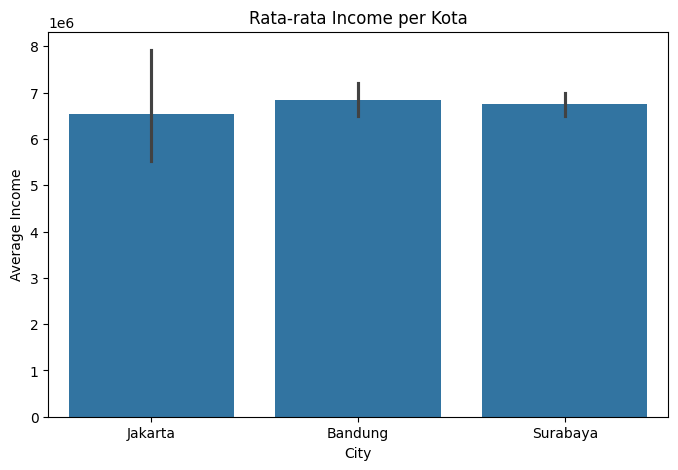

In [26]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_clean, x="city", y="income", estimator=np.mean)
plt.title("Rata-rata Income per Kota")
plt.xlabel("City")
plt.ylabel("Average Income")
plt.show()

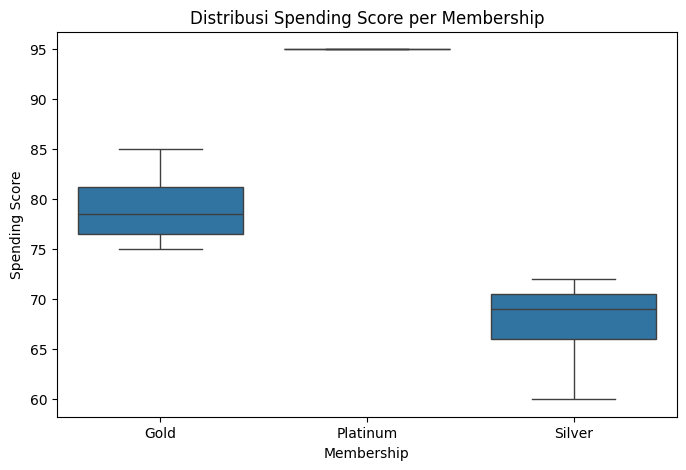

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="membership", y="spending_score")
plt.title("Distribusi Spending Score per Membership")
plt.xlabel("Membership")
plt.ylabel("Spending Score")
plt.show()

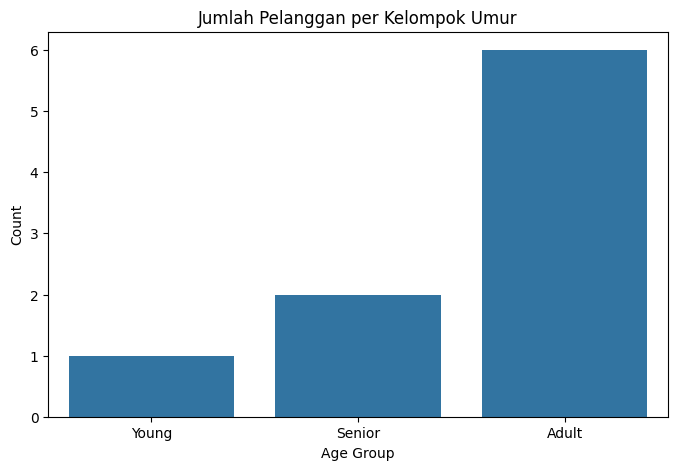

In [28]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="age_group")
plt.title("Jumlah Pelanggan per Kelompok Umur")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

## 14. Menyiapkan Dataset Final untuk Machine Learning

Setelah proses wrangling selesai, biasanya kita menyiapkan dataset final yang siap dipakai untuk model.  
Artinya:
- missing values sudah ditangani,
- duplikasi sudah dibersihkan,
- fitur kategorikal sudah di-encode,
- dan fitur tambahan sudah dibuat jika diperlukan.

In [29]:
final_df = df_encoded.copy()

print("Shape final dataset:", final_df.shape)
display(final_df.head())

Shape final dataset: (9, 21)


,customer_id,name,age,income,membership,spending_score,high_income,membership_encoded,city_Bandung,city_Jakarta,city_Surabaya,gender_F,gender_M,gender_Unknown,age_group_Adult,age_group_Senior,age_group_Young,spending_category_High,spending_category_Low,spending_category_Medium,spending_category_Very High
0,1,Andi,23,5000000.0,Silver,60,0,1,False,True,False,False,True,False,False,False,True,False,True,False,False
1,2,Budi,35,7200000.0,Gold,80,1,2,True,False,False,False,True,False,False,True,False,True,False,False,False
2,3,Citra,32,6100000.0,Silver,70,0,1,False,True,False,True,False,False,True,False,False,False,False,True,False
3,4,Dina,29,6500000.0,Gold,85,0,2,False,False,True,True,False,False,True,False,False,False,False,False,True
4,5,Eka,41,9000000.0,Platinum,95,1,3,False,True,False,True,False,False,False,True,False,False,False,False,True


In [30]:
print("Daftar kolom final:")
for col in final_df.columns:
    print(col)

Daftar kolom final:
customer_id
name
age
income
membership
spending_score
high_income
membership_encoded
city_Bandung
city_Jakarta
city_Surabaya
gender_F
gender_M
gender_Unknown
age_group_Adult
age_group_Senior
age_group_Young
spending_category_High
spending_category_Low
spending_category_Medium
spending_category_Very High


## 15. Contoh Memisahkan Fitur dan Target

Sebagai simulasi sederhana, kita anggap `high_income` sebagai target klasifikasi.  
Tujuannya bukan membangun model terbaik pada chapter ini, tetapi menunjukkan bagaimana hasil wrangling bisa langsung disiapkan untuk machine learning.

In [31]:
target = "high_income"

X = final_df.drop(columns=[target, "name", "membership"])
y = final_df[target]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

display(X.head())
display(y.head())

Shape X: (9, 18)
Shape y: (9,)


,customer_id,age,income,spending_score,membership_encoded,city_Bandung,city_Jakarta,city_Surabaya,gender_F,gender_M,gender_Unknown,age_group_Adult,age_group_Senior,age_group_Young,spending_category_High,spending_category_Low,spending_category_Medium,spending_category_Very High
0,1,23,5000000.0,60,1,False,True,False,False,True,False,False,False,True,False,True,False,False
1,2,35,7200000.0,80,2,True,False,False,False,True,False,False,True,False,True,False,False,False
2,3,32,6100000.0,70,1,False,True,False,True,False,False,True,False,False,False,False,True,False
3,4,29,6500000.0,85,2,False,False,True,True,False,False,True,False,False,False,False,False,True
4,5,41,9000000.0,95,3,False,True,False,True,False,False,False,True,False,False,False,False,True


,high_income
0,0
1,1
2,0
3,0
4,1


## 16. Insight Singkat dari Hasil Wrangling

Dari proses di atas, kita bisa melihat beberapa hal penting:
- missing values berhasil ditangani dengan strategi yang sesuai,
- data duplikat telah dibersihkan,
- kategori telah diubah menjadi representasi numerik,
- dan beberapa fitur baru berhasil ditambahkan untuk memperkaya informasi.

Tahapan seperti ini sangat penting karena kualitas preprocessing akan sangat memengaruhi kualitas model machine learning di tahap berikutnya.

In [32]:
summary_table = pd.DataFrame({
    "Aspek": [
        "Jumlah data awal",
        "Jumlah data setelah hapus duplikat",
        "Jumlah kolom awal",
        "Jumlah kolom final setelah encoding",
        "Missing value tersisa"
    ],
    "Nilai": [
        df.shape[0],
        df_clean.shape[0],
        df.shape[1],
        final_df.shape[1],
        int(final_df.isnull().sum().sum())
    ]
})

summary_table

,Aspek,Nilai
0,Jumlah data awal,10
1,Jumlah data setelah hapus duplikat,9
2,Jumlah kolom awal,8
3,Jumlah kolom final setelah encoding,21
4,Missing value tersisa,0


## 17. Kesimpulan Chapter 2

Chapter 2 menekankan bahwa sebelum membangun model machine learning, data harus dipersiapkan dengan baik terlebih dahulu.  
Melalui pandas, kita dapat melakukan banyak proses penting seperti:

- membaca dan memahami struktur data,
- memilih subset data yang relevan,
- memfilter data sesuai kebutuhan,
- menangani missing values,
- menghapus data duplikat,
- membersihkan tipe data,
- membuat fitur baru,
- melakukan encoding pada fitur kategorikal,
- serta merangkum data dengan groupby dan agregasi.

Inti dari chapter ini adalah bahwa **data wrangling bukan sekadar tahap tambahan**, tetapi merupakan fondasi penting agar data siap dipakai dalam pipeline machine learning.

In [33]:
final_df.to_csv("chapter2_clean_dataset.csv", index=False)
print("Dataset hasil wrangling disimpan sebagai chapter2_clean_dataset.csv")

Dataset hasil wrangling disimpan sebagai chapter2_clean_dataset.csv
